# Sentiment Analysis with RNN, LSTM, and GRU
## A Complete Educational Guide for Beginners

---

### What will you learn?

By the end of this notebook, you will understand:

1. **What is Sentiment Analysis?** — Detecting whether text is positive or negative
2. **How text is processed** — Tokenization, vocabulary, and encoding
3. **What are Word Embeddings?** — Representing words as numbers
4. **How RNNs work** — Networks that process sequences
5. **How LSTMs and GRUs improve on RNNs** — Better memory mechanisms
6. **How to train and evaluate models** — The full ML pipeline
7. **How to deploy a model as an API** — Real-world usage with FastAPI

---

### No deep ML experience required!
Each section is explained from first principles. Code is kept short and heavily commented.

> **Dataset**: IMDb Movie Reviews — 50,000 reviews labeled as Positive or Negative

## Setup: Install Required Libraries

Run this cell once to install all dependencies.
- **torch**: Deep learning framework (PyTorch)
- **datasets**: HuggingFace library to download datasets easily
- **sklearn**: Machine learning tools (metrics, etc.)
- **matplotlib / seaborn**: For plotting graphs

In [1]:
# Install all required packages
# Run this cell once — it may take a few minutes
!pip install torch torchtext datasets pandas numpy matplotlib seaborn scikit-learn fastapi uvicorn tensorboard tqdm Pillow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "C:\Python314\Lib\site-packages\pip\_internal\cli\base_command.py", line 107, in _run_wrapper
    status = _inner_run()
  File "C:\Python314\Lib\site-packages\pip\_internal\cli\base_command.py", line 98, in _inner_run
    return self.run(options, args)
           ~~~~~~~~^^^^^^^^^^^^^^^
  File "C:\Python314\Lib\site-packages\pip\_internal\cli\req_command.py", line 85, in wrapper
    return func(self, options, args)
  File "C:\Python314\Lib\site-packages\pip\_internal\commands\install.py", line 308, in run
    options.use_user_site = decide_user_install(
                            ~~~~~~~~~~~~~~~~~~~^
        options.use_user_site,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
        isolated_mode=options.isolated_mode,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Python314\L

## Step 1: Load the IMDb Dataset

### What is the IMDb Dataset?
- **50,000 movie reviews** from the Internet Movie Database (IMDb)
- **25,000** for training, **25,000** for testing
- Each review is labeled: **1 = Positive**, **0 = Negative**

We use HuggingFace's `datasets` library to download it automatically.

### Why split data into Train/Validation/Test?
| Split | Purpose |
|-------|--------|
| Train (80%) | Model learns from this data |
| Validation (10%) | Monitor training, tune hyperparameters |
| Test (10%) | Final evaluation — model has NEVER seen this |

In [2]:
import sys
import os

# Add project root to Python path so we can import our modules
project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Load the IMDb dataset
from ingestion.loader import load_imdb_as_dataframe

train_df, val_df, test_df = load_imdb_as_dataframe()

print("\nColumn names:", train_df.columns.tolist())
print("\nFirst review (first 200 chars):")
print(train_df['text'][0][:200])
print("\nLabel:", train_df['label'][0], "(1=positive, 0=negative)")

Loading IMDb dataset...


Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset loaded successfully:
  Train:      20000 examples
  Validation: 2500 examples
  Test:       25000 examples

Column names: ['text', 'label']

First review (first 200 chars):
Dumb is as dumb does, in this thoroughly uninteresting, supposed black comedy. Essentially what starts out as Chris Klein trying to maintain a low profile, eventually morphs into an uninspired version

Label: 0 (1=positive, 0=negative)


## Step 2: Explore the Data (EDA — Exploratory Data Analysis)

Before building any model, always **explore your data** first.

Key questions to ask:
- Are the classes balanced? (Equal positive/negative?)
- How long are the reviews?
- Are there any weird values?

> **Why does class balance matter?**  
> If 90% of reviews are positive, a model can get 90% accuracy by always predicting "positive"! That's not a real model.

In [3]:
import pandas as pd

# Look at first 5 rows
print("=== First 5 rows ===")
print(train_df.head())

print("\n=== Label Distribution ===")
print(train_df['label'].value_counts())
print("  0 = Negative, 1 = Positive")

# Compute review lengths (number of words)
train_df['review_length'] = train_df['text'].apply(lambda x: len(x.split()))

print("\n=== Review Length Statistics ===")
print(train_df['review_length'].describe().round(1))

=== First 5 rows ===
                                                text  label
0  Dumb is as dumb does, in this thoroughly unint...      0
1  I dug out from my garage some old musicals and...      1
2  After watching this movie I was honestly disap...      0
3  This movie was nominated for best picture but ...      1
4  Just like Al Gore shook us up with his painful...      1

=== Label Distribution ===
label
0    10038
1     9962
Name: count, dtype: int64
  0 = Negative, 1 = Positive



=== Review Length Statistics ===
count    20000.0
mean       234.0
std        173.8
min         10.0
25%        127.0
50%        175.0
75%        285.0
max       2470.0
Name: review_length, dtype: float64


## Step 3: Visualize the Data

Visualizations help us understand the data at a glance.

We will plot:
1. **Label distribution** — How many positive vs negative reviews?
2. **Review length distribution** — How long are most reviews?

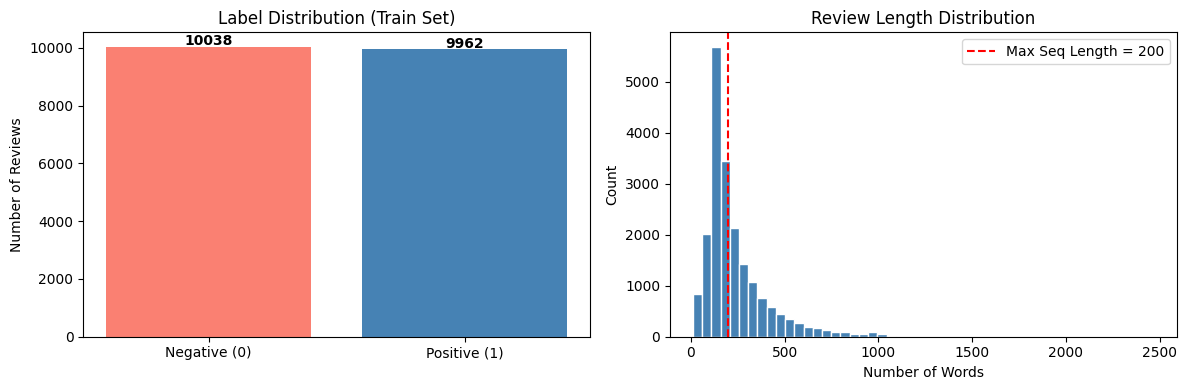

The dataset is balanced (equal positive and negative reviews)!


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Label Distribution
label_counts = train_df['label'].value_counts()
ax1.bar(['Negative (0)', 'Positive (1)'], label_counts.values, color=['salmon', 'steelblue'])
ax1.set_title('Label Distribution (Train Set)')
ax1.set_ylabel('Number of Reviews')
for i, v in enumerate(label_counts.values):
    ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')

# Plot 2: Review Length Distribution
ax2.hist(train_df['review_length'], bins=50, color='steelblue', edgecolor='white')
ax2.axvline(200, color='red', linestyle='--', label='Max Seq Length = 200')
ax2.set_title('Review Length Distribution')
ax2.set_xlabel('Number of Words')
ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.show()
print("The dataset is balanced (equal positive and negative reviews)!")

## Step 4: Tokenization

### What is Tokenization?
**Tokenization** splits raw text into smaller units called **tokens** (usually words).

This is the **first step** in every NLP pipeline.

```
Raw text:  "The movie was GREAT! <br/> Loved it."
    ↓  lowercase
           "the movie was great! <br/> loved it."
    ↓  remove HTML
           "the movie was great!  loved it."
    ↓  remove punctuation
           "the movie was great  loved it"
    ↓  split
Tokens:   ['the', 'movie', 'was', 'great', 'loved', 'it']
```

> **Why lowercase?** So "Movie" and "movie" are treated as the same word.

> **Why remove HTML?** IMDb reviews contain tags like `<br />` that aren't meaningful.

In [5]:
from processing.tokenizer import simple_tokenize

# Example tokenization
sample_text = "The movie was GREAT! <br/> Absolutely LOVED it. A must-watch film!"
tokens = simple_tokenize(sample_text)

print("Original text:")
print(sample_text)
print("\nAfter tokenization:")
print(tokens)
print(f"\nNumber of tokens: {len(tokens)}")

# Tokenize a real review from our dataset
real_review = train_df['text'][0]
real_tokens = simple_tokenize(real_review)
print(f"\nReal review token count: {len(real_tokens)}")
print("First 10 tokens:", real_tokens[:10])

Original text:
The movie was GREAT! <br/> Absolutely LOVED it. A must-watch film!

After tokenization:
['the', 'movie', 'was', 'great', 'absolutely', 'loved', 'it', 'a', 'mustwatch', 'film']

Number of tokens: 10

Real review token count: 114
First 10 tokens: ['dumb', 'is', 'as', 'dumb', 'does', 'in', 'this', 'thoroughly', 'uninteresting', 'supposed']


## Step 5: Build the Vocabulary

### What is a Vocabulary?
A **vocabulary** is a dictionary that maps every word to a unique integer ID.

Neural networks cannot process words — they need **numbers**.

```
Word       →  Index
"<PAD>"   →  0      (special: padding)
"<UNK>"   →  1      (special: unknown words)
"the"     →  2      (most common word)
"movie"   →  3
"great"   →  4
...
```

### Special Tokens:
| Token | Index | Purpose |
|-------|-------|---------|
| `<PAD>` | 0 | Fill short sequences to equal length |
| `<UNK>` | 1 | Replace words not seen during training |

> We build the vocabulary ONLY from training data. Test words not in vocab become `<UNK>`.

In [6]:
from processing.pipeline import build_vocab_from_df

# Build vocabulary from training data only!
vocab = build_vocab_from_df(train_df)

print(f"Vocabulary size: {vocab.vocab_size}")

# Look up some words
test_words = ['the', 'movie', 'great', 'terrible', 'love', 'hate', 'xyz123notaword']
print("\nWord -> Index mapping:")
for word in test_words:
    idx = vocab.word_to_idx.get(word, 1)  # 1 = UNK
    print(f"  '{word}' -> {idx}")

# Top 10 most common words
print("\nFirst 10 words in vocabulary (most frequent):")
for word, idx in list(vocab.word_to_idx.items())[2:12]:  # skip PAD and UNK
    print(f"  [{idx}] {word}")

Building vocabulary from training data...


Vocabulary built: 10002 words
Vocabulary size: 10002

Word -> Index mapping:
  'the' -> 2
  'movie' -> 17
  'great' -> 85
  'terrible' -> 380
  'love' -> 113
  'hate' -> 763
  'xyz123notaword' -> 1

First 10 words in vocabulary (most frequent):
  [2] the
  [3] and
  [4] a
  [5] of
  [6] to
  [7] is
  [8] in
  [9] it
  [10] i
  [11] this


## Step 6: Encode and Pad Sequences

### The Full Preprocessing Pipeline

After tokenization and vocabulary building, we need to:

1. **Encode**: Convert tokens to integer IDs using the vocabulary
2. **Truncate**: Cut sequences longer than MAX_SEQ_LEN (200 words)
3. **Pad**: Add `<PAD>` (index 0) to sequences shorter than 200 words

**Why padding?** Neural networks need all input sequences to be the **same length** so they can be batched together as a matrix.

```
Review A: [2, 45, 67, 12]          → length 4
Review B: [2, 11, 5, 3, 19, 8]     → length 6

After padding to length 6:
Review A: [2, 45, 67, 12, 0, 0]    → length 6 (padded)
Review B: [2, 11, 5, 3, 19, 8]     → length 6 (unchanged)
```

In [7]:
from processing.tokenizer import simple_tokenize
from config.settings import MAX_SEQ_LEN, PAD_IDX

def encode_and_pad(text, vocab, max_len=MAX_SEQ_LEN):
    """Show the full preprocessing pipeline step by step."""
    tokens  = simple_tokenize(text)          # Step 1: Tokenize
    encoded = vocab.encode(tokens)           # Step 2: Encode to IDs
    encoded = encoded[:max_len]              # Step 3: Truncate
    padded  = encoded + [PAD_IDX] * (max_len - len(encoded))  # Step 4: Pad
    return tokens, encoded, padded

sample = "This film was absolutely wonderful. I loved every minute of it!"
tokens, encoded, padded = encode_and_pad(sample, vocab)

print("Original:", sample)
print("\nTokens:", tokens)
print("\nEncoded (first 12):", encoded[:12])
print(f"\nPadded (length={len(padded)}), first 15:", padded[:15])
print(f"\nNumber of <PAD> tokens: {padded.count(0)}")

Original: This film was absolutely wonderful. I loved every minute of it!

Tokens: ['this', 'film', 'was', 'absolutely', 'wonderful', 'i', 'loved', 'every', 'minute', 'of', 'it']

Encoded (first 12): [11, 19, 13, 415, 370, 10, 429, 171, 795, 5, 9]

Padded (length=200), first 15: [11, 19, 13, 415, 370, 10, 429, 171, 795, 5, 9, 0, 0, 0, 0]

Number of <PAD> tokens: 189


## Step 7: Word Embeddings

### What are Word Embeddings?

Once words are encoded as integers, we need to convert them to **dense vectors** (lists of floats) before feeding them into a neural network.

**Why not use the integer directly?**
- Integer 5 ≠ 5 times as important as integer 1
- Integers don't capture semantic similarity

**Embeddings solve this:**
- Each word gets a unique vector of size `EMBEDDING_DIM` (e.g., 64 floats)
- Similar words get similar vectors!
- The model **learns** these vectors during training

```
"king"   → [0.21, -0.45, 0.72, 0.11, ...]  (64 numbers)
"queen"  → [0.19, -0.42, 0.71, 0.13, ...]  (similar!)
"pizza"  → [-0.83, 0.12, -0.44, 0.55, ...] (different)
```

> This is the same idea as **Word2Vec** and **GloVe** — famous embedding methods.

In [8]:
import torch
import torch.nn as nn
from config.settings import EMBEDDING_DIM, PAD_IDX

# Create an embedding layer
embedding = nn.Embedding(
    num_embeddings=vocab.vocab_size,  # One vector per word
    embedding_dim=EMBEDDING_DIM,      # Size of each vector (64)
    padding_idx=PAD_IDX               # PAD always gets zero vector
)

# Convert a sample sentence to embedding vectors
sample_ids = torch.tensor([[2, 45, 67, 12, 0, 0]])  # shape: (1, 6)
embedded   = embedding(sample_ids)                   # shape: (1, 6, 64)

print(f"Input shape (batch, seq_len):           {sample_ids.shape}")
print(f"Output shape (batch, seq_len, emb_dim): {embedded.shape}")
print(f"\nEmbedding for word index 2 (first 8 values):")
print(embedded[0, 0, :8].detach().numpy().round(3))
print(f"\nEmbedding for PAD (index 0) — should be all zeros:")
print(embedded[0, 4, :8].detach().numpy().round(3))

Input shape (batch, seq_len):           torch.Size([1, 6])
Output shape (batch, seq_len, emb_dim): torch.Size([1, 6, 64])

Embedding for word index 2 (first 8 values):
[-0.558  1.342 -0.857  1.156  0.384 -1.109 -1.728 -0.395]

Embedding for PAD (index 0) — should be all zeros:
[0. 0. 0. 0. 0. 0. 0. 0.]


## Step 8: RNN Architecture

### How does an RNN work?

A **Recurrent Neural Network (RNN)** processes sequences one element at a time, maintaining a **hidden state** that acts as memory.

```
Input sequence: ["the", "movie", "was", "great"]

Step 1: RNN reads "the"   → hidden state h1
Step 2: RNN reads "movie" → hidden state h2  (using h1)
Step 3: RNN reads "was"   → hidden state h3  (using h2)
Step 4: RNN reads "great" → hidden state h4  (using h3)

h4 = summary of the entire sentence → passed to classifier
```

**Architecture:**
```
Text IDs → Embedding → RNN → Dropout → Linear → Sigmoid → Prediction
```

### Limitation of RNNs:
> For very long sequences, RNNs "forget" early words.  
> This is called the **vanishing gradient problem**.

In [9]:
from models.rnn_model import RNNModel
from config.settings import HIDDEN_DIM, EMBEDDING_DIM, NUM_LAYERS

# Create the RNN model
rnn_model = RNNModel(vocab_size=vocab.vocab_size)
print("RNN Model Architecture:")
print(rnn_model)

# Count total parameters
total_params = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

# Test a forward pass
dummy_input = torch.randint(0, vocab.vocab_size, (4, 200))  # batch=4, seq_len=200
output = rnn_model(dummy_input)
print(f"\nInput shape:  {dummy_input.shape}  (batch_size=4, seq_len=200)")
print(f"Output shape: {output.shape}          (one score per review)")
print(f"Sample scores (raw, before sigmoid): {output.detach().numpy().round(3)}")

RNN Model Architecture:
RNNModel(
  (embedding): Embedding(10002, 64, padding_idx=0)
  (rnn): RNN(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Total trainable parameters: 665,089

Input shape:  torch.Size([4, 200])  (batch_size=4, seq_len=200)
Output shape: torch.Size([4])          (one score per review)
Sample scores (raw, before sigmoid): [ 0.507 -0.228 -0.082  0.22 ]


## Step 9: LSTM Architecture

### How does LSTM fix the RNN problem?

**LSTM (Long Short-Term Memory)** adds a **cell state** — a separate long-term memory lane.

Three **gates** control what information flows through:

| Gate | Question it answers |
|------|---------------------|
| **Forget gate** | What old information should I discard? |
| **Input gate** | What new information should I store? |
| **Output gate** | What information should I output right now? |

```
RNN:  one state  → h
LSTM: two states → h (short-term) + c (long-term cell state)
```

**Result:** LSTMs can remember information across **hundreds of words** — solving the vanishing gradient problem!

In [10]:
from models.lstm_model import LSTMModel

# Create the LSTM model
lstm_model = LSTMModel(vocab_size=vocab.vocab_size)
print("LSTM Model Architecture:")
print(lstm_model)

lstm_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
rnn_params  = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)

print(f"\nParameter Comparison:")
print(f"  RNN parameters:  {rnn_params:,}")
print(f"  LSTM parameters: {lstm_params:,}")
print(f"  LSTM has ~{lstm_params/rnn_params:.1f}x more parameters than RNN")
print("  (More parameters = more capacity to learn, but slower to train)")

# Test forward pass
lstm_out = lstm_model(dummy_input)
print(f"\nLSTM output shape: {lstm_out.shape}")

LSTM Model Architecture:
LSTMModel(
  (embedding): Embedding(10002, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Parameter Comparison:
  RNN parameters:  665,089
  LSTM parameters: 739,585
  LSTM has ~1.1x more parameters than RNN
  (More parameters = more capacity to learn, but slower to train)



LSTM output shape: torch.Size([4])


## Step 10: GRU Architecture

### GRU: The Best of Both Worlds

**GRU (Gated Recurrent Unit)** is a simplified version of LSTM:

| Feature | RNN | LSTM | GRU |
|---------|-----|------|-----|
| Memory gates | None | 3 gates | 2 gates |
| States | h only | h + cell state | h only |
| Parameters | Fewest | Most | Medium |
| Training speed | Fastest | Slowest | Fast |
| Long-range memory | Poor | Excellent | Good |

**GRU gates:**
- **Reset gate**: How much past memory to forget
- **Update gate**: How much of old vs new information to keep

> In practice, GRU often achieves similar accuracy to LSTM with fewer parameters and faster training.

In [11]:
from models.gru_model import GRUModel

# Create GRU model
gru_model = GRUModel(vocab_size=vocab.vocab_size)
gru_params = sum(p.numel() for p in gru_model.parameters() if p.requires_grad)

print("GRU Model Architecture:")
print(gru_model)

print(f"\n=== Parameter Count Summary ===")
print(f"  RNN:  {rnn_params:>10,} parameters")
print(f"  LSTM: {lstm_params:>10,} parameters")
print(f"  GRU:  {gru_params:>10,} parameters")

# Test forward pass
gru_out = gru_model(dummy_input)
print(f"\nGRU output shape: {gru_out.shape}")

GRU Model Architecture:
GRUModel(
  (embedding): Embedding(10002, 64, padding_idx=0)
  (gru): GRU(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

=== Parameter Count Summary ===
  RNN:     665,089 parameters
  LSTM:    739,585 parameters
  GRU:     714,753 parameters



GRU output shape: torch.Size([4])


## Step 11: The Training Loop

### How does a neural network learn?

Training a neural network repeats these 4 steps for each batch of data:

```
1. FORWARD PASS
   Input text → model → prediction (e.g., 0.7 = probably positive)

2. COMPUTE LOSS
   Compare prediction (0.7) to true label (1.0)
   Loss = measure of how wrong the prediction is

3. BACKWARD PASS (Backpropagation)
   Calculate how to adjust each weight to reduce loss
   (Using calculus: gradients)

4. CLIP GRADIENTS
   Cap gradient magnitudes to prevent exploding gradients
   (Critical for RNNs — max_norm=1.0)

5. UPDATE WEIGHTS
   Optimizer nudges each weight in the right direction
   (We use Adam optimizer with learning_rate=0.003)
```

This repeats for up to **5 epochs** (5 full passes over all training data), with early stopping if validation loss stops improving for 3 epochs in a row.

> **Loss function**: `BCEWithLogitsLoss` = Binary Cross Entropy (for 0/1 classification)

In [ ]:
from processing.pipeline import create_dataloaders
from training.trainer import train_one_epoch, evaluate
from training.early_stopping import EarlyStopping
from config.settings import LEARNING_RATE
import torch.nn as nn

# Create DataLoaders
train_loader, val_loader, test_loader = create_dataloaders(train_df, val_df, test_df, vocab)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set up model, optimizer, and loss function
rnn = RNNModel(vocab.vocab_size).to(device)
optimizer = torch.optim.Adam(rnn.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()  # Binary cross entropy with sigmoid built in

# Train for just 2 epochs in this notebook (full training is in main.py)
print("\nTraining RNN for 2 epochs (demo)...")
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, 3):
    train_loss, train_acc = train_one_epoch(rnn, train_loader, optimizer, criterion, device)
    val_loss, val_acc     = evaluate(rnn, val_loader, criterion, device)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Acc={val_acc:.4f}")

## Step 12: Evaluation

### How do we measure model performance?

Accuracy alone is not enough. We use 4 metrics:

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Accuracy** | (TP+TN) / Total | Overall correct predictions |
| **Precision** | TP / (TP+FP) | Of predicted positives, how many are really positive? |
| **Recall** | TP / (TP+FN) | Of actual positives, how many did we catch? |
| **F1 Score** | 2*(P*R)/(P+R) | Balance between precision and recall |

**Confusion Matrix:**
```
              Predicted Negative  Predicted Positive
Actual Neg:        TN (correct)       FP (wrong)
Actual Pos:        FN (wrong)         TP (correct)
```


  RNN (2 epochs demo) Evaluation Results
  Accuracy:  0.5052
  Precision: 0.5033
  Recall:    0.7991
  F1 Score:  0.6176



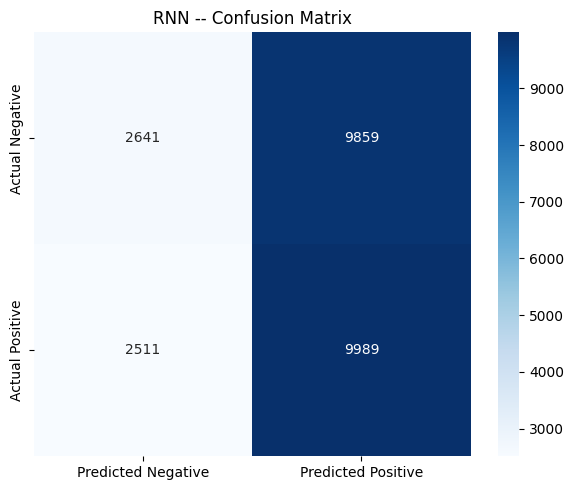

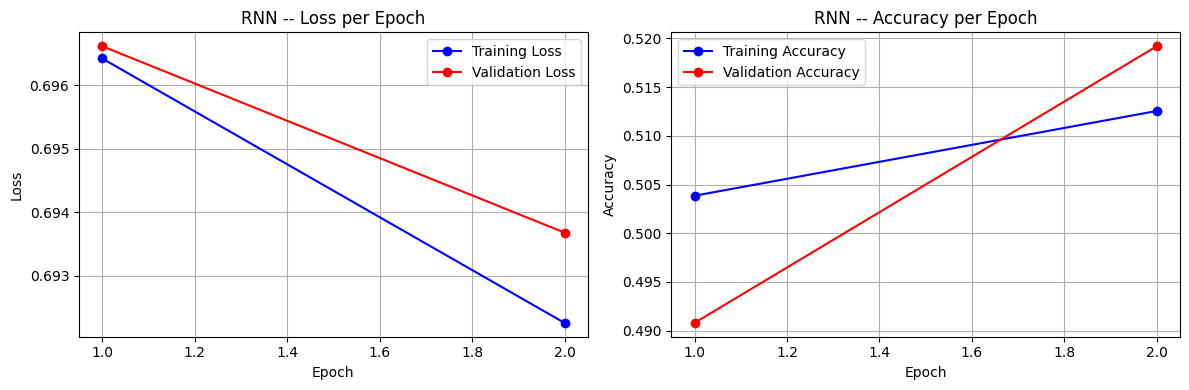

In [13]:
from evaluation.metrics import get_predictions, compute_metrics, print_metrics
from evaluation.plots import plot_training_history, plot_confusion_matrix

# Get predictions on test set
true_labels, pred_labels = get_predictions(rnn, test_loader, device)

# Compute all metrics
metrics = compute_metrics(true_labels, pred_labels)
print_metrics(metrics, "RNN (2 epochs demo)")

# Plot confusion matrix
plot_confusion_matrix(metrics['confusion_matrix'], "RNN")

# Plot training history
plot_training_history(history, "RNN")

## Step 13: Model Comparison

### Comparing RNN vs LSTM vs GRU

When we run `main.py` (the full training script), all three models are trained and compared.

Here we simulate a comparison with dummy results to show you the comparison plot format.

**In practice (after running main.py), you typically see:**

| Model | Accuracy | F1 Score | Training Speed |
|-------|----------|----------|----------------|
| RNN | ~75-80% | ~0.76 | Fastest |
| LSTM | ~85-88% | ~0.86 | Slowest |
| GRU | ~84-87% | ~0.85 | Medium |

> LSTM and GRU significantly outperform vanilla RNN because of their gating mechanisms.

=== Simulated Model Comparison ===
(Run main.py for real results)

RNN: Accuracy=78.00%, F1=78.00%
LSTM: Accuracy=87.00%, F1=87.00%
GRU: Accuracy=86.00%, F1=86.00%


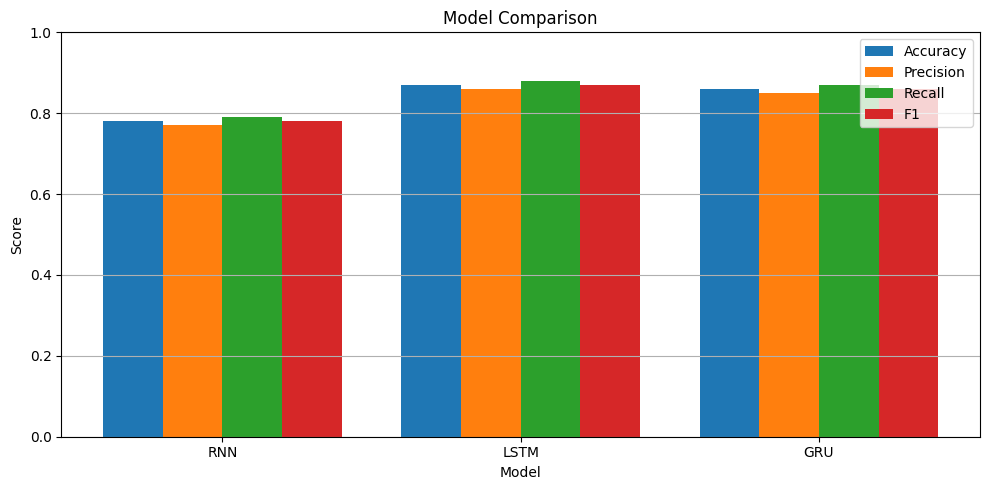

In [14]:
from evaluation.plots import plot_model_comparison

# Simulated results (replace with real results after running main.py)
simulated_results = {
    "RNN":  {"accuracy": 0.78, "precision": 0.77, "recall": 0.79, "f1": 0.78},
    "LSTM": {"accuracy": 0.87, "precision": 0.86, "recall": 0.88, "f1": 0.87},
    "GRU":  {"accuracy": 0.86, "precision": 0.85, "recall": 0.87, "f1": 0.86},
}

print("=== Simulated Model Comparison ===")
print("(Run main.py for real results)\n")
for model_name, results in simulated_results.items():
    print(f"{model_name}: Accuracy={results['accuracy']:.2%}, F1={results['f1']:.2%}")

# Plot comparison chart
plot_model_comparison(simulated_results)

## Step 14: Inference — Making Predictions on New Text

### What is Inference?

**Inference** means using a trained model to make predictions on **new, unseen data**.

The inference pipeline applies the **same preprocessing** as during training:

```
New review text
    ↓  tokenize
Word tokens
    ↓  encode
Integer IDs
    ↓  pad/truncate to length 200
Fixed-length sequence
    ↓  convert to tensor
    ↓  run through model
    ↓  apply sigmoid
Probability (0.0 to 1.0)
    ↓  threshold at 0.5
POSITIVE or NEGATIVE
```

In [15]:
from inference.predictor import predict_sentiment

# Test reviews to classify
test_reviews = [
    "This movie was absolutely amazing! The acting was superb and the story was captivating.",
    "Terrible film. Boring plot, bad acting, and a complete waste of time. Would not recommend.",
    "It was okay. Not great, not terrible. Some good parts and some slow parts.",
    "One of the best films I have ever seen. A true masterpiece of cinema!",
    "Awful. I fell asleep halfway through. The director had no idea what they were doing."
]

print("Sentiment Predictions (using 2-epoch RNN demo model):")
print("-" * 60)
for review in test_reviews:
    result = predict_sentiment(review, rnn, vocab, device)
    emoji = "POSITIVE" if result['sentiment'] == 'positive' else "NEGATIVE"
    print(f"[{emoji}] ({result['confidence']:.0%} confident)")
    print(f"  '{review[:70]}...'" if len(review) > 70 else f"  '{review}'")
    print()

Sentiment Predictions (using 2-epoch RNN demo model):
------------------------------------------------------------
[POSITIVE] (50% confident)
  'This movie was absolutely amazing! The acting was superb and the story...'

[POSITIVE] (50% confident)
  'Terrible film. Boring plot, bad acting, and a complete waste of time. ...'

[POSITIVE] (50% confident)
  'It was okay. Not great, not terrible. Some good parts and some slow pa...'

[POSITIVE] (50% confident)
  'One of the best films I have ever seen. A true masterpiece of cinema!'

[POSITIVE] (50% confident)
  'Awful. I fell asleep halfway through. The director had no idea what th...'



## Step 15: FastAPI Deployment

### How do we serve the model to users?

After training, we can deploy the model as a **REST API** using FastAPI.

**What is an API?**  
An API (Application Programming Interface) lets other programs talk to your model over the internet.

### How to run the API:

**Step 1**: Train the models first
```bash
python main.py
```

**Step 2**: Start the API server
```bash
uvicorn api.app:app --reload
```

**Step 3**: Open your browser at `http://localhost:8000/docs`  
You'll see an interactive Swagger UI!

**Step 4**: Send a prediction request:
```bash
curl -X POST "http://localhost:8000/predict" \
     -H "Content-Type: application/json" \
     -d '{"text": "This movie was fantastic!"}'
```

**Response:**
```json
{
  "sentiment": "positive",
  "confidence": 0.95,
  "score": 0.95,
  "text": "This movie was fantastic!"
}
```

In [16]:
# Preview the API code (api/app.py)
# This shows the key parts of the FastAPI application

api_preview = '''
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="Sentiment Analysis API")

class PredictRequest(BaseModel):
    text: str  # The review to classify

class PredictResponse(BaseModel):
    sentiment:  str    # "positive" or "negative"
    confidence: float  # 0.0 to 1.0
    score:      float  # raw sigmoid output
    text:       str    # echo back the input

@app.post("/predict", response_model=PredictResponse)
def predict(request: PredictRequest):
    result = predict_sentiment(request.text, model, vocab, device)
    result['text'] = request.text
    return PredictResponse(**result)
'''

print("Key API code (from api/app.py):")
print(api_preview)
print("\nTo start the API server, run in your terminal:")
print("  uvicorn api.app:app --reload")
print("\nThen visit: http://localhost:8000/docs")

Key API code (from api/app.py):

from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="Sentiment Analysis API")

class PredictRequest(BaseModel):
    text: str  # The review to classify

class PredictResponse(BaseModel):
    sentiment:  str    # "positive" or "negative"
    confidence: float  # 0.0 to 1.0
    score:      float  # raw sigmoid output
    text:       str    # echo back the input

@app.post("/predict", response_model=PredictResponse)
def predict(request: PredictRequest):
    result = predict_sentiment(request.text, model, vocab, device)
    result['text'] = request.text
    return PredictResponse(**result)


To start the API server, run in your terminal:
  uvicorn api.app:app --reload

Then visit: http://localhost:8000/docs


## Summary and Next Steps

### What we built

Congratulations! You have built a **complete end-to-end NLP sentiment analysis system**:

```
Raw text
  → Tokenization      (split into words)
  → Vocabulary        (word to integer mapping)
  → Encoding          (words → integers)
  → Padding           (equal-length sequences)
  → Embedding         (integers → dense vectors)
  → RNN / LSTM / GRU  (sequence modeling)
  → Classification    (positive / negative)
  → FastAPI           (deployed as web service)
```

---

### Key Takeaways

| Concept | What it does |
|---------|-------------|
| **Tokenization** | Splits raw text into words |
| **Vocabulary** | Maps words to integers |
| **Embeddings** | Maps integers to dense vectors |
| **RNN** | Processes sequences, suffers from vanishing gradient |
| **LSTM** | Adds cell state and 3 gates, solves vanishing gradient |
| **GRU** | Simpler than LSTM, still great performance |
| **Dropout** | Prevents overfitting |
| **Early Stopping** | Stops training when validation loss stops improving |
| **FastAPI** | Serves the model as a REST API |

---

### Next Steps to Explore

1. **Run `main.py`** — Train all 3 models on the full IMDb dataset
2. **Try Bidirectional LSTM** — Process sequences forward AND backward
3. **Try pre-trained embeddings** — Use GloVe or FastText embeddings
4. **Try Transformers** — The state of the art (BERT, RoBERTa)
5. **Try different datasets** — Twitter sentiment, product reviews, news
6. **Improve the API** — Add authentication, rate limiting, logging
7. **Monitor with TensorBoard** — Run `tensorboard --logdir=runs`

---

### Run the full project:

```bash
# Train all models
python main.py

# Start the API
uvicorn api.app:app --reload

# Monitor training
tensorboard --logdir=runs
```

Happy learning!

In [17]:
# Final summary: print the project structure
import os

project_files = [
    "config/settings.py       - All hyperparameters in one place",
    "data/download.py         - Download IMDb dataset",
    "ingestion/loader.py      - Load and split dataset",
    "processing/tokenizer.py  - Text tokenization",
    "processing/vocabulary.py - Word-to-index mapping",
    "processing/pipeline.py   - Full data pipeline + DataLoaders",
    "embeddings/embedding_layer.py - Word embedding creation",
    "models/rnn_model.py      - Vanilla RNN model",
    "models/lstm_model.py     - LSTM model",
    "models/gru_model.py      - GRU model",
    "training/trainer.py      - Training and evaluation loops",
    "training/early_stopping.py - Early stopping callback",
    "evaluation/metrics.py    - Accuracy, F1, confusion matrix",
    "evaluation/plots.py      - Training curves and comparison plots",
    "monitoring/tensorboard_logger.py - TensorBoard logging",
    "inference/predictor.py   - Single-text prediction pipeline",
    "api/app.py               - FastAPI REST endpoint",
    "main.py                  - Training entry point",
]

print("=" * 60)
print("  PROJECT FILE SUMMARY")
print("=" * 60)
for f in project_files:
    print(f"  {f}")
print("=" * 60)
print("\nRun 'python main.py' to train all models!")

  PROJECT FILE SUMMARY
  config/settings.py       - All hyperparameters in one place
  data/download.py         - Download IMDb dataset
  ingestion/loader.py      - Load and split dataset
  processing/tokenizer.py  - Text tokenization
  processing/vocabulary.py - Word-to-index mapping
  processing/pipeline.py   - Full data pipeline + DataLoaders
  embeddings/embedding_layer.py - Word embedding creation
  models/rnn_model.py      - Vanilla RNN model
  models/lstm_model.py     - LSTM model
  models/gru_model.py      - GRU model
  training/trainer.py      - Training and evaluation loops
  training/early_stopping.py - Early stopping callback
  evaluation/metrics.py    - Accuracy, F1, confusion matrix
  evaluation/plots.py      - Training curves and comparison plots
  monitoring/tensorboard_logger.py - TensorBoard logging
  inference/predictor.py   - Single-text prediction pipeline
  api/app.py               - FastAPI REST endpoint
  main.py                  - Training entry point

Run 'pyt